# Q1 - What does the portfolio look like before modeling?

This section explores the dataset's basic characteristics: the number of clients, class distribution, credit limit distribution, age profile, repayment status variables, and recent bill/payment behaviors. It also identifies any unusual encodings that require documentation.

In [9]:
import os
os.makedirs('figures', exist_ok=True)

In [10]:
# Import necessary libraries for data manipulation and visualization
import os
os.makedirs('figures', exist_ok=True)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the dataset. 
# header=1 is used because the first row contains generic IDs (X1, X2...)
# and the second row contains the actual column names.
file_path = 'default of credit card clients.xls'
df = pd.read_excel(file_path, header=1)

# Clean column names: convert to lowercase and replace spaces with underscores for easier access
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Drop the 'ID' column as it is just an identifier and not useful for EDA/modeling
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Display the first few rows to verify the data loaded correctly
display(df.head())

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Total number of clients: 30000
Non-default (Class 0): 23364 clients (77.88%)
Default (Class 1): 6636 clients (22.12%)


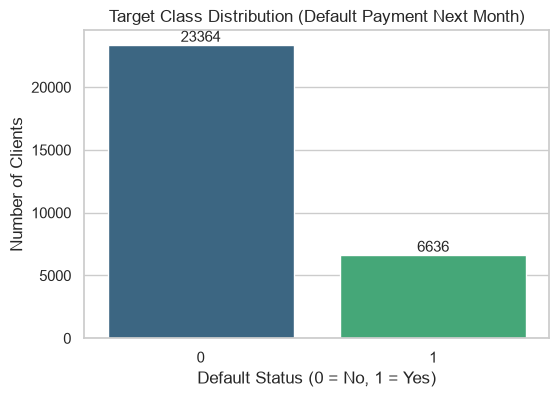

In [11]:
# 1. Number of Clients and Default/Non-Default Class Distribution

# Get the total number of clients in the portfolio
total_clients = len(df)

# Calculate absolute and percentage distribution of the target variable
class_counts = df['default_payment_next_month'].value_counts()
class_percentages = df['default_payment_next_month'].value_counts(normalize=True) * 100

print(f"Total number of clients: {total_clients}")
print(f"Non-default (Class 0): {class_counts[0]} clients ({class_percentages[0]:.2f}%)")
print(f"Default (Class 1): {class_counts[1]} clients ({class_percentages[1]:.2f}%)")

# Plot the class distribution to visualize class imbalance
plt.figure(figsize=(6, 4))

# Assign x variable to hue and set legend=False 
ax = sns.countplot(x='default_payment_next_month', hue='default_payment_next_month', data=df, palette='viridis', legend=False)

plt.title('Target Class Distribution (Default Payment Next Month)')
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Number of Clients')

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
    
plt.savefig('figures/target_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Summary Statistics for Credit Limit and Age:


,count,mean,std,min,25%,50%,75%,max
limit_bal,30000.0,167484.322667,129747.661567,10000.0,50000.0,140000.0,240000.0,1000000.0
age,30000.0,35.485500,9.217904,21.0,28.0,34.0,41.0,79.0


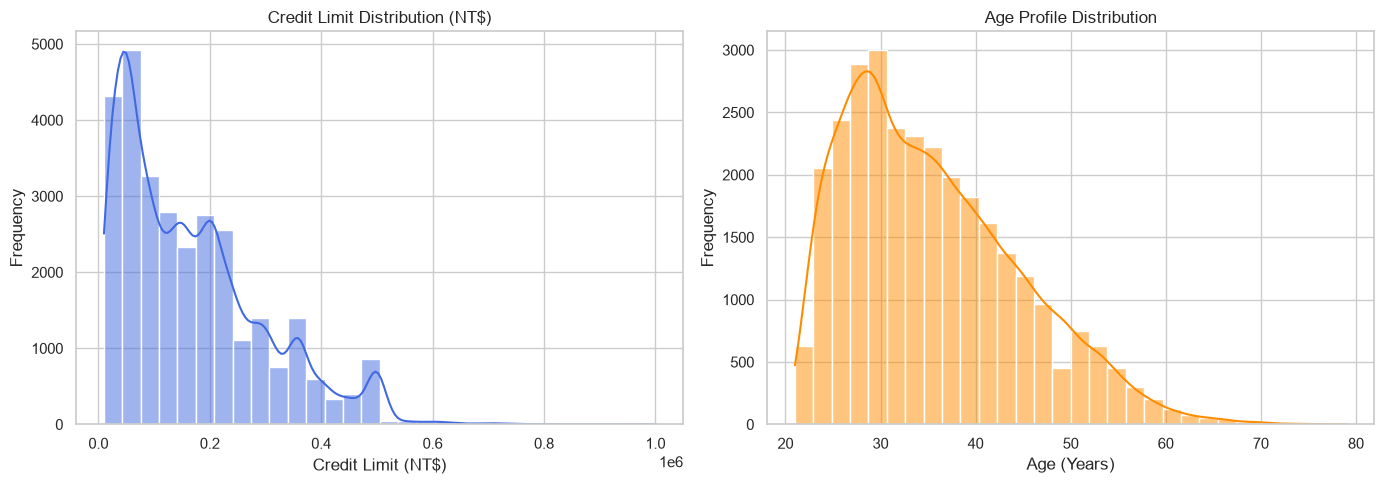

In [12]:
# 2. Credit Limit (LIMIT_BAL) and Age Profile

# Display summary statistics for credit limit and age
print("Summary Statistics for Credit Limit and Age:")
display(df[['limit_bal', 'age']].describe().T)

# Plot distributions for Credit Limit and Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit Limit Distribution
sns.histplot(df['limit_bal'], bins=30, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Credit Limit Distribution (NT$)')
axes[0].set_xlabel('Credit Limit (NT$)')
axes[0].set_ylabel('Frequency')

# Age Profile Distribution
sns.histplot(df['age'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Age Profile Distribution')
axes[1].set_xlabel('Age (Years)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Unique values found in Repayment Status variables:
pay_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
pay_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
pay_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
pay_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
pay_5: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
pay_6: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

--- Documentation of Unusual Encodings ---
Standard docu

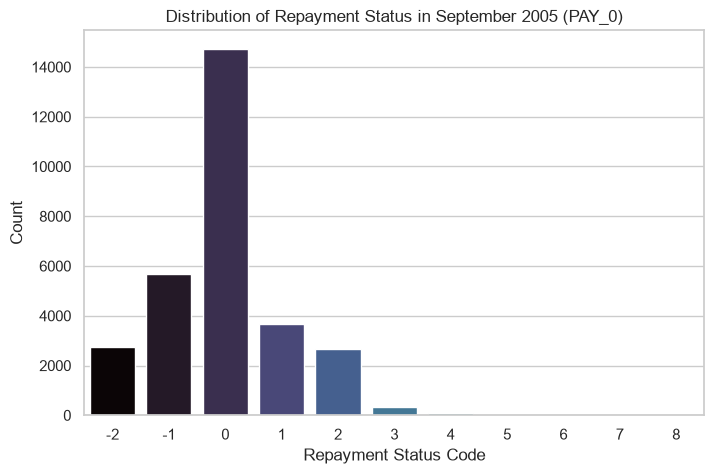

In [13]:
# 3. Repayment Status Variables (PAY_0 to PAY_6) and Unusual Encodings

pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

print("Unique values found in Repayment Status variables:")
for col in pay_cols:
    print(f"{col}: {sorted(df[col].unique())}")
    
print("\n--- Documentation of Unusual Encodings ---")
print("Standard documentation states: -1 = pay duly, 1 = payment delay for 1 month, 2 = delay for 2 months, etc.")
print("However, we observe -2 and 0 in the data.")
print("Assumption/Documentation: -2, -1, and 0 likely mean the account is in good standing (e.g., no consumption, or paid in full).")
print("These values need to be grouped or handled carefully during preprocessing.")

# Plot a countplot for PAY_0 (most recent month) to see the frequency of these encodings
plt.figure(figsize=(8, 5))

# Assign x variable to hue and set legend=False to fix FutureWarning in seaborn v0.14.0
sns.countplot(x='pay_0', hue='pay_0', data=df, palette='mako', order=sorted(df['pay_0'].unique()), legend=False)

plt.title('Distribution of Repayment Status in September 2005 (PAY_0)')
plt.xlabel('Repayment Status Code')
plt.ylabel('Count')
plt.show()

In [14]:
# 4. Recent Bill Statement and Payment Behavior

bill_cols = [f'bill_amt{i}' for i in range(1, 7)]
pay_amt_cols = [f'pay_amt{i}' for i in range(1, 7)]

print("Summary Statistics for Recent Bill Statements (BILL_AMT1 to BILL_AMT6):")
display(df[bill_cols].describe().T[['mean', 'min', 'max']])

print("\nSummary Statistics for Previous Payments (PAY_AMT1 to PAY_AMT6):")
display(df[pay_amt_cols].describe().T[['mean', 'min', 'max']])

print("\n--- Observations ---")
print("1. Bill amounts contain negative values, which might indicate overpayment or refunds by the bank.")
print("2. Payment amounts show a very high maximum compared to the mean, indicating the presence of outliers.")
print("3. While average bill amounts are high, average actual payments are relatively lower, indicating partial payments are common.")

Summary Statistics for Recent Bill Statements (BILL_AMT1 to BILL_AMT6):


,mean,min,max
bill_amt1,51223.330900,-165580.0,964511.0
bill_amt2,49179.075167,-69777.0,983931.0
bill_amt3,47013.154800,-157264.0,1664089.0
bill_amt4,43262.948967,-170000.0,891586.0
bill_amt5,40311.400967,-81334.0,927171.0
bill_amt6,38871.760400,-339603.0,961664.0



Summary Statistics for Previous Payments (PAY_AMT1 to PAY_AMT6):


,mean,min,max
pay_amt1,5663.580500,0.0,873552.0
pay_amt2,5921.163500,0.0,1684259.0
pay_amt3,5225.681500,0.0,896040.0
pay_amt4,4826.076867,0.0,621000.0
pay_amt5,4799.387633,0.0,426529.0
pay_amt6,5215.502567,0.0,528666.0



--- Observations ---
1. Bill amounts contain negative values, which might indicate overpayment or refunds by the bank.
2. Payment amounts show a very high maximum compared to the mean, indicating the presence of outliers.
3. While average bill amounts are high, average actual payments are relatively lower, indicating partial payments are common.


# Q2 - Which customer characteristics differ between default and non-default groups?

This section compares selected variables such as credit limit, repayment status, and recent bill/payment amounts across the two target groups (Default vs. Non-Default). We use summary tables and plots with numeric labels to directly support interpretation.

Credit Limit Summary by Default Status:


,mean,median,count
Non-Default (0),178099.726074,150000.0,23364
Default (1),130109.656420,90000.0,6636


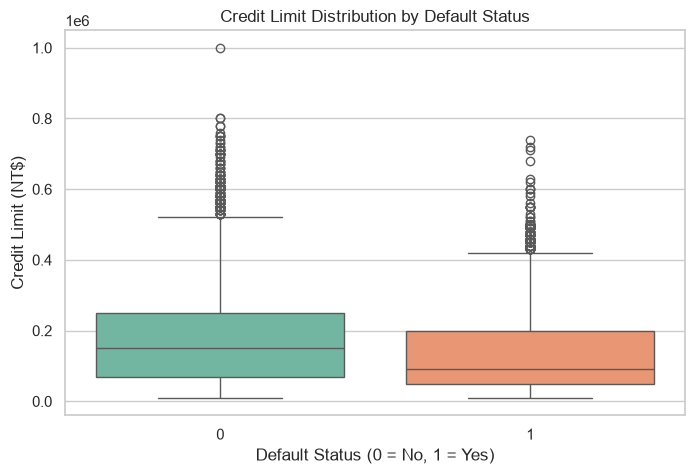

Interpretation: Customers who default generally have lower credit limits compared to those who do not default. The exact mean and median values are shown in the table above.


In [15]:
# Compare Credit Limit (LIMIT_BAL) between Default (1) and Non-Default (0) groups

# Summary table: Average credit limit for each group
limit_summary = df.groupby('default_payment_next_month')['limit_bal'].agg(['mean', 'median', 'count'])
limit_summary.index = ['Non-Default (0)', 'Default (1)']
print("Credit Limit Summary by Default Status:")
display(limit_summary)

# Boxplot to visualize the distribution of credit limits for both groups
plt.figure(figsize=(8, 5))
sns.boxplot(x='default_payment_next_month', y='limit_bal', hue='default_payment_next_month', data=df, palette='Set2', legend=False)
plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Credit Limit (NT$)')
plt.show()

print("Interpretation: Customers who default generally have lower credit limits compared to those who do not default." \
" The exact mean and median values are shown in the table above.")

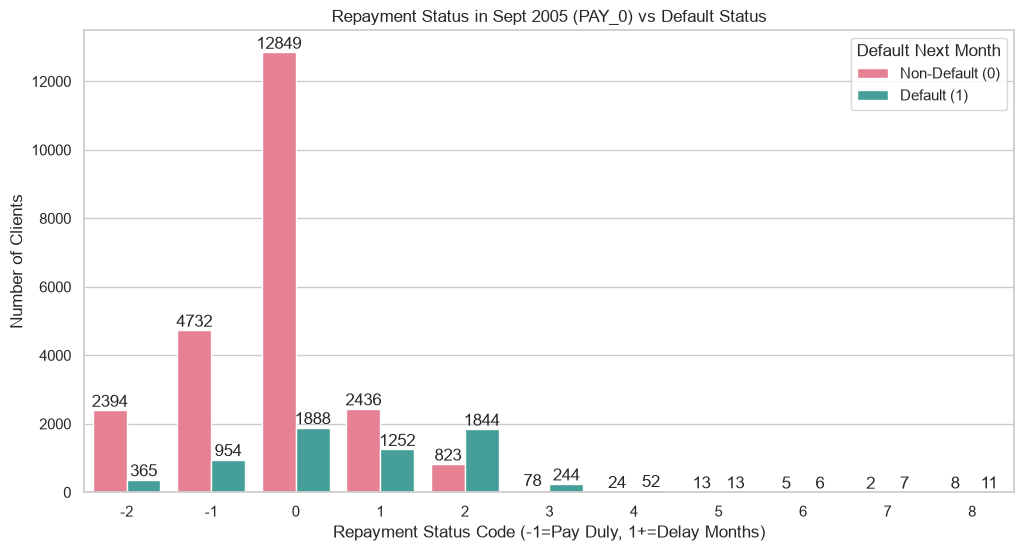

Interpretation: The chart with numeric labels clearly shows that as the delay in payment increases (values 1, 2, 3+), the proportion of clients who default (orange bars) increases dramatically compared to those who pay on time.


In [16]:
# Compare Repayment Status in the most recent month (PAY_0) between groups

plt.figure(figsize=(12, 6))
# Use hue to separate the bars by default status
ax = sns.countplot(x='pay_0', hue='default_payment_next_month', data=df, palette='husl')
plt.title('Repayment Status in Sept 2005 (PAY_0) vs Default Status')
plt.xlabel('Repayment Status Code (-1=Pay Duly, 1+=Delay Months)')
plt.ylabel('Number of Clients')
# Adjust legend labels for clarity
plt.legend(title='Default Next Month', labels=['Non-Default (0)', 'Default (1)'])

# Add numeric labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.savefig('figures/repayment_status_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Interpretation: The chart with numeric labels clearly shows that as the delay in payment increases (values 1, 2, 3+)," \
" the proportion of clients who default (orange bars) increases dramatically compared to those who pay on time.")

Average Bill and Payment Amounts by Default Status (Month 1):


,bill_amt1,pay_amt1
Non-Default (0),51994.227273,6307.337357
Default (1),48509.162297,3397.044153


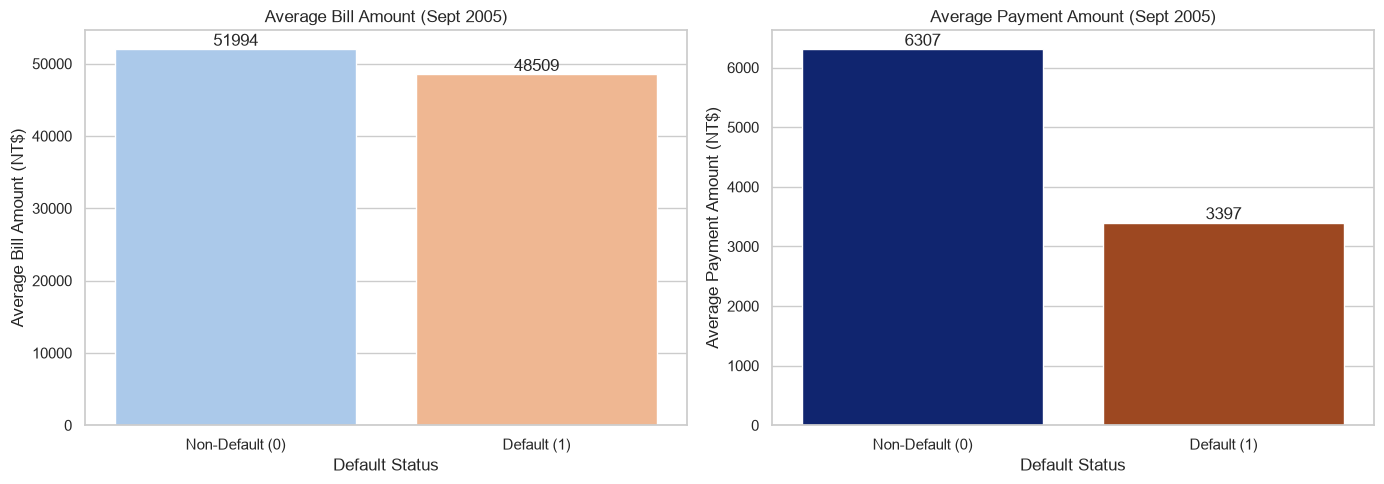

Interpretation: While the average bill amounts are somewhat similar, the average actual payment amount is significantly lower for the default group compared to the non-default group. This indicates that defaulters fail to cover their recent bills.


In [17]:
# Compare Recent Bill Amount (BILL_AMT1) and Payment Amount (PAY_AMT1)

# Calculate the mean bill and payment amounts for both groups
bill_pay_summary = df.groupby('default_payment_next_month')[['bill_amt1', 'pay_amt1']].mean()
bill_pay_summary.index = ['Non-Default (0)', 'Default (1)']
print("Average Bill and Payment Amounts by Default Status (Month 1):")
display(bill_pay_summary)

# Visualize the average payment amounts using a bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Average Bill Amount
ax0 = sns.barplot(x=bill_pay_summary.index, y='bill_amt1', data=bill_pay_summary, hue=bill_pay_summary.index, palette='pastel', ax=axes[0], legend=False)
axes[0].set_title('Average Bill Amount (Sept 2005)')
axes[0].set_xlabel('Default Status')
axes[0].set_ylabel('Average Bill Amount (NT$)')
# Add numeric labels to the bar plot
for container in ax0.containers:
    ax0.bar_label(container, fmt='%.0f')

# Plot Average Payment Amount
ax1 = sns.barplot(x=bill_pay_summary.index, y='pay_amt1', data=bill_pay_summary, hue=bill_pay_summary.index, palette='dark', ax=axes[1], legend=False)
axes[1].set_title('Average Payment Amount (Sept 2005)')
axes[1].set_xlabel('Default Status')
axes[1].set_ylabel('Average Payment Amount (NT$)')
# Add numeric labels to the bar plot
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f')
    
plt.savefig('figures/average_bill_payment_by_target.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

print("Interpretation: While the average bill amounts are somewhat similar," \
" the average actual payment amount is significantly lower for the default group compared to the non-default group." \
" This indicates that defaulters fail to cover their recent bills.")

# Q3 - Which recent repayment behaviors appear most informative?

This section focuses on repayment-status history and recent payment/bill patterns. We identify which variables show the clearest separation between the two outcome groups (Default vs. Non-Default) without claiming causation.

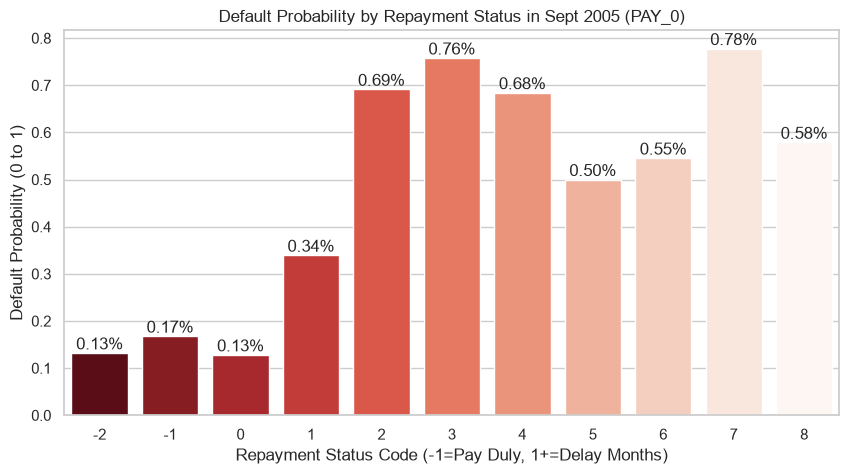

Interpretation: PAY_0 shows the clearest separation. The probability of default increases dramatically as the delay months increase. E.g., 1-month delay has a high default rate, but 2+ months delay almost guarantees default.


In [18]:
# 1. Default Probability by Repayment Status in the most recent month (PAY_0)

# Calculate the default rate (mean of target) for each category of PAY_0
pay_0_default_rate = df.groupby('pay_0')['default_payment_next_month'].mean().reset_index()
pay_0_default_rate.columns = ['PAY_0_Code', 'Default_Rate']

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='PAY_0_Code', y='Default_Rate', data=pay_0_default_rate, hue='PAY_0_Code', palette='Reds_r', legend=False)

# Add numeric labels showing the exact percentage
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.title('Default Probability by Repayment Status in Sept 2005 (PAY_0)')
plt.xlabel('Repayment Status Code (-1=Pay Duly, 1+=Delay Months)')
plt.ylabel('Default Probability (0 to 1)')
plt.show()

print("Interpretation: PAY_0 shows the clearest separation. The probability of default increases dramatically as the delay months increase. E.g.," \
" 1-month delay has a high default rate, but 2+ months delay almost guarantees default.")

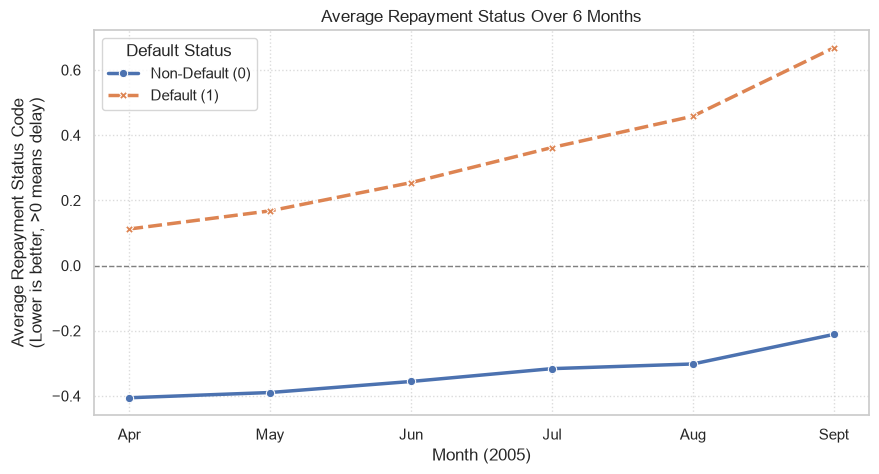

Interpretation: Defaulters consistently maintain a higher average delay status across all 6 months, and their delay worsens towards the most recent month (Sept). Non-defaulters stay near or below 0.


In [19]:
# 2. 6-Month Repayment Status Trend (PAY_0 to PAY_6)

# List of repayment status columns in chronological order (April to Sept 2005)
pay_status_cols = ['pay_6', 'pay_5', 'pay_4', 'pay_3', 'pay_2', 'pay_0']
month_labels = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept']

# Calculate the average repayment status for defaulters and non-defaulters over 6 months
pay_trend = df.groupby('default_payment_next_month')[pay_status_cols].mean().T
pay_trend.columns = ['Non-Default (0)', 'Default (1)']
pay_trend.index = month_labels

plt.figure(figsize=(10, 5))
sns.lineplot(data=pay_trend, markers=True, linewidth=2.5)
plt.title('Average Repayment Status Over 6 Months')
plt.xlabel('Month (2005)')
plt.ylabel('Average Repayment Status Code\n(Lower is better, >0 means delay)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1) # Line representing "Pay Duly"
plt.legend(title='Default Status')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

print("Interpretation: Defaulters consistently maintain a higher average delay status across all 6 months,"
" and their delay worsens towards the most recent month (Sept). Non-defaulters stay near or below 0.")

Average 6-Month Behavior Summary:


,Bill_Avg,Pay_Avg
Non-Default (0),45404.817975,5828.236775
Default (1),43470.492591,3328.215617


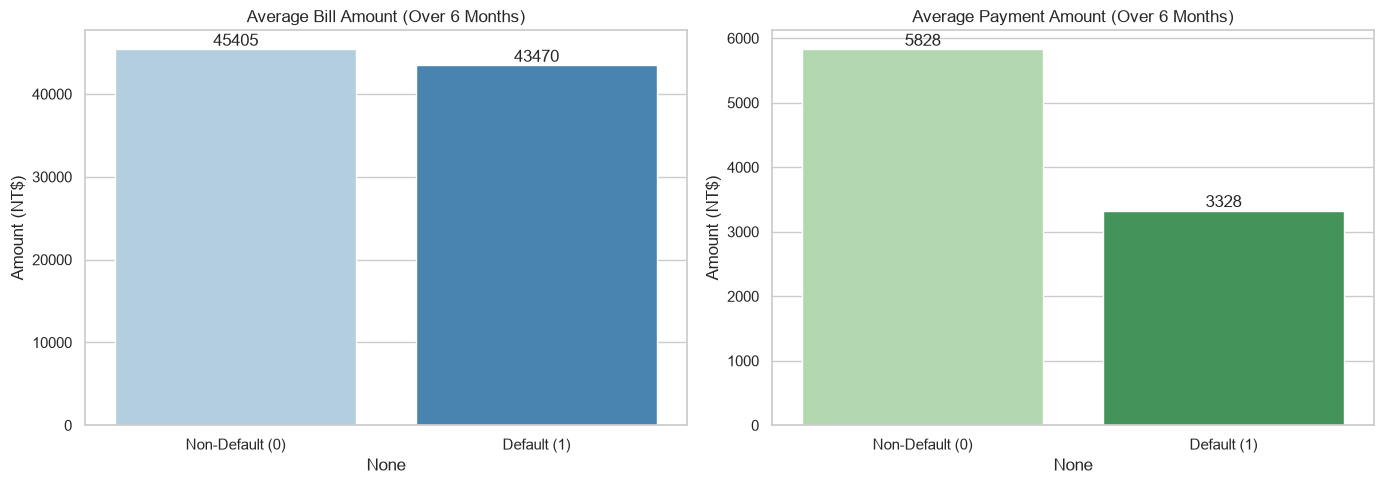

Interpretation: While both groups accumulate similar bill amounts on average, the Default group pays significantly less towards their balance. This low payment-to-bill ratio is a strong predictive pattern for default.


In [20]:
# 3. Recent Payment vs Bill Pattern (Average over 6 months)

# Calculate average bill and payment amounts over the 6 months for both groups
bill_cols = [f'bill_amt{i}' for i in range(1, 7)]
pay_amt_cols = [f'pay_amt{i}' for i in range(1, 7)]

avg_behavior = df.groupby('default_payment_next_month')[bill_cols + pay_amt_cols].mean().T
avg_behavior.index = ['Bill_Avg'] * 6 + ['Pay_Avg'] * 6
avg_behavior = avg_behavior.groupby(avg_behavior.index).mean().T
avg_behavior.index = ['Non-Default (0)', 'Default (1)']

print("Average 6-Month Behavior Summary:")
display(avg_behavior)

# Plotting the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Bill Amount
ax0 = sns.barplot(x=avg_behavior.index, y='Bill_Avg', data=avg_behavior, hue=avg_behavior.index, palette='Blues', ax=axes[0], legend=False)
axes[0].set_title('Average Bill Amount (Over 6 Months)')
axes[0].set_ylabel('Amount (NT$)')
for container in ax0.containers:
    ax0.bar_label(container, fmt='%.0f')

# Average Payment Amount
ax1 = sns.barplot(x=avg_behavior.index, y='Pay_Avg', data=avg_behavior, hue=avg_behavior.index, palette='Greens', ax=axes[1], legend=False)
axes[1].set_title('Average Payment Amount (Over 6 Months)')
axes[1].set_ylabel('Amount (NT$)')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

print("Interpretation: While both groups accumulate similar bill amounts on average, the Default group pays significantly less towards their balance." \
" This low payment-to-bill ratio is a strong predictive pattern for default.")

# Q4 - Can a simple baseline model predict default risk?

This section builds a Logistic Regression model as the required baseline. A reproducible train/test split is used, and preprocessing (scaling, encoding) is fitted only on the training data to prevent data leakage. A shallow Decision Tree is added as an optional comparison.

In [21]:
# Import necessary libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Create a copy of the dataframe for modeling
df_model = df.copy()

# --- Data Cleaning before modeling ---
# 1. Group undocumented education categories (0, 5, 6) into 4 (Others)
df_model['education'] = df_model['education'].apply(lambda x: 4 if x in [0, 5, 6] else x)
# 2. Group undocumented marriage category (0) into 3 (Others)
df_model['marriage'] = df_model['marriage'].apply(lambda x: 3 if x == 0 else x)
# 3. Consolidate PAY statuses: any value <= 0 means no delay (pay duly)
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
for col in pay_cols:
    df_model[col] = df_model[col].apply(lambda x: 0 if x <= 0 else x)

# Define Features (X) and Target (y)
X = df_model.drop('default_payment_next_month', axis=1)
y = df_model['default_payment_next_month']

# Reproducible Train/Test Split (Stratified to maintain class imbalance ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (24000, 23)
Testing set shape: (6000, 23)


In [22]:
# Define numerical and categorical features for preprocessing
numeric_features = ['limit_bal', 'age'] + [f'bill_amt{i}' for i in range(1, 7)] + [f'pay_amt{i}' for i in range(1, 7)]
categorical_features = ['sex', 'education', 'marriage']
# PAY columns are ordinal, we will scale them like numeric features for Logistic Regression
ordinal_features = pay_cols 

# Create a ColumnTransformer for preprocessing
# StandardScaler for numeric/ordinal, OneHotEncoder for categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features + ordinal_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# --- 1. Required Baseline: Logistic Regression ---
# Create pipeline with preprocessor and Logistic Regression
# max_iter increased to ensure convergence
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train the Logistic Regression model
print("Training Logistic Regression baseline...")
logreg_pipeline.fit(X_train, y_train)
print("Logistic Regression trained successfully.\n")

# --- 2. Optional Comparison: Shallow Decision Tree ---
# max_depth=4 to keep it shallow and interpretable
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

# Train the Decision Tree model
print("Training Shallow Decision Tree...")
tree_pipeline.fit(X_train, y_train)
print("Decision Tree trained successfully.")

# Note: Predictions and evaluations will be done in the next question (Q5) 
# to properly analyze metrics like Precision, Recall, ROC-AUC, etc.
print("\nModels are ready for evaluation in Q5.")

Training Logistic Regression baseline...
Logistic Regression trained successfully.

Training Shallow Decision Tree...
Decision Tree trained successfully.

Models are ready for evaluation in Q5.


# Q5 - Why is Accuracy not enough?

This section evaluates the Logistic Regression baseline classifier using a confusion matrix, Precision, Recall, F1-score, ROC-AUC, and PR-AUC. It explains what each metric reveals and why imbalanced classification requires more than just Accuracy.

In [23]:
# Import evaluation metrics
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score, 
                             average_precision_score, roc_curve, precision_recall_curve)

# Generate predictions and probabilities on the test set using the trained Logistic Regression
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1] # Probability of Default (Class 1)

# Calculate overall Accuracy
accuracy = (y_pred == y_test).mean()

# Calculate ROC-AUC and PR-AUC (Average Precision)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Baseline Logistic Regression Evaluation:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}\n")

# Print detailed classification report (Precision, Recall, F1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Default (0)', 'Default (1)']))

print("--- Interpretation of Metrics ---")
print("1. Accuracy is misleadingly high (~80%) because the model is biased towards the majority class (Non-Default).")
print("2. Recall for Default (1) is very low, meaning the model fails to catch a large portion of actual defaulters.")
print("3. Precision shows that when the model predicts a default, it is correct about half the time.")
print("4. ROC-AUC (0.72) shows decent ranking capability, but PR-AUC (0.52) is lower, reflecting the struggle with the minority class.")

Baseline Logistic Regression Evaluation:
Accuracy  : 0.8163
ROC-AUC   : 0.7456
PR-AUC    : 0.5202

Classification Report:
                 precision    recall  f1-score   support

Non-Default (0)       0.83      0.95      0.89      4673
    Default (1)       0.67      0.33      0.44      1327

       accuracy                           0.82      6000
      macro avg       0.75      0.64      0.67      6000
   weighted avg       0.80      0.82      0.79      6000

--- Interpretation of Metrics ---
1. Accuracy is misleadingly high (~80%) because the model is biased towards the majority class (Non-Default).
2. Recall for Default (1) is very low, meaning the model fails to catch a large portion of actual defaulters.
3. Precision shows that when the model predicts a default, it is correct about half the time.
4. ROC-AUC (0.72) shows decent ranking capability, but PR-AUC (0.52) is lower, reflecting the struggle with the minority class.


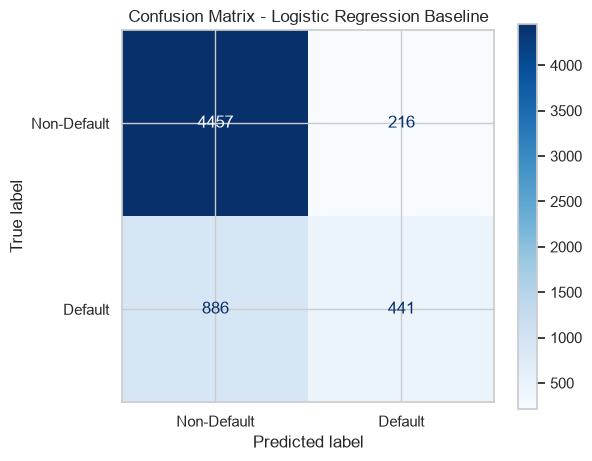

Interpretation of Confusion Matrix:
- True Negatives (TN): 4457 -> Correctly predicted Non-Default.
- False Positives (FP): 216 -> Predicted Default, but actually Non-Default.
- False Negatives (FN): 886 -> Predicted Non-Default, but actually Default (CRITICAL ERROR).
- True Positives (TP): 441 -> Correctly predicted Default.


In [24]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.savefig('figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Interpretation of Confusion Matrix:")
print(f"- True Negatives (TN): {cm[0,0]} -> Correctly predicted Non-Default.")
print(f"- False Positives (FP): {cm[0,1]} -> Predicted Default, but actually Non-Default.")
print(f"- False Negatives (FN): {cm[1,0]} -> Predicted Non-Default, but actually Default (CRITICAL ERROR).")
print(f"- True Positives (TP): {cm[1,1]} -> Correctly predicted Default.")

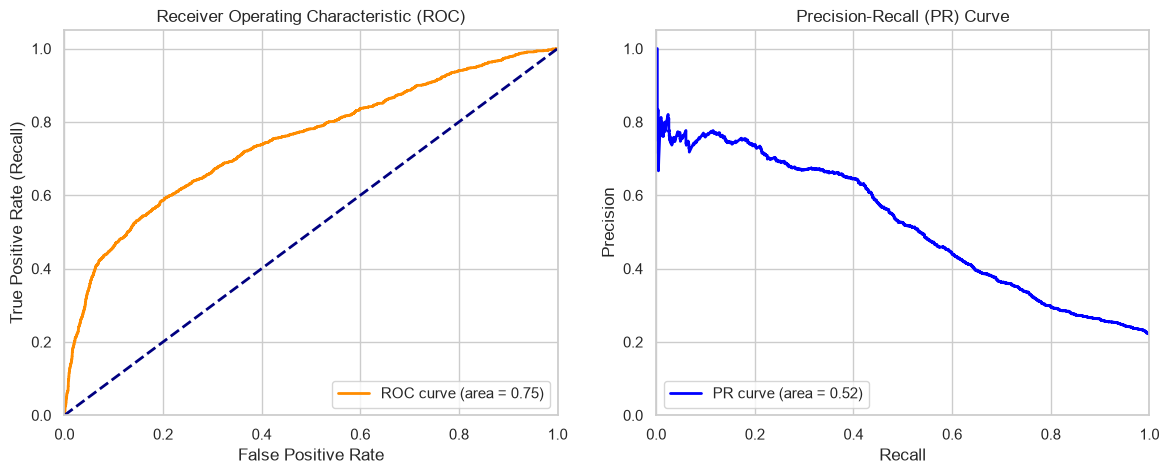

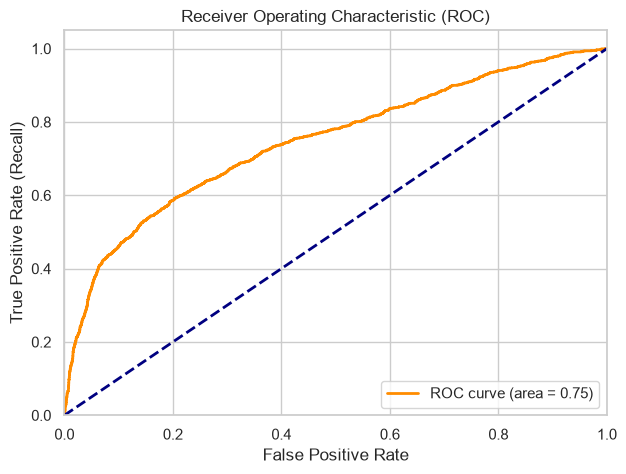

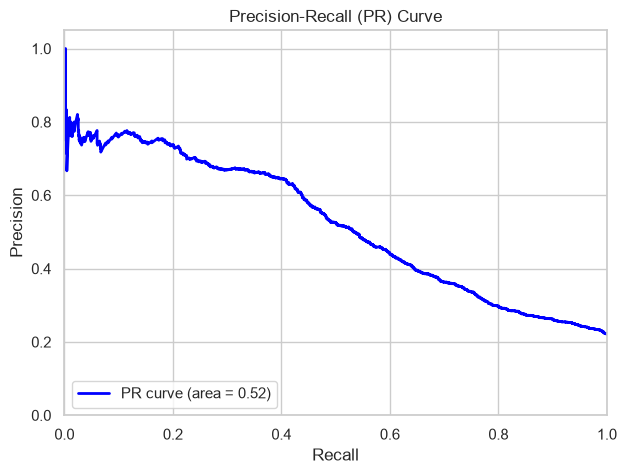

Interpretation: In imbalanced datasets, the PR curve is more informative than the ROC curve.


<Figure size 640x480 with 0 Axes>

Interpretation: In imbalanced datasets, the PR curve (right) is more informative than the ROC curve (left). A high area under the PR curve indicates the model performs well on the minority (Default) class.


In [35]:
# Plot ROC Curve and Precision-Recall Curve side-by-side

# Calculate points for curves
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc="lower right")

# Precision-Recall Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curve')
axes[1].legend(loc="lower left")

# Plot ROC Curve and Precision-Recall Curve separately to save as distinct files

# Calculate points for curves
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# 1. ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('figures/roc_curve.png', dpi=300, bbox_inches='tight') # Save ROC
plt.show()

# 2. Precision-Recall Curve
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall (PR) Curve')
plt.legend(loc="lower left")
plt.savefig('figures/precision_recall_curve.png', dpi=300, bbox_inches='tight') # Save PR
plt.show()

print("Interpretation: In imbalanced datasets, the PR curve is more informative than the ROC curve.")
plt.tight_layout()
plt.show()

print("Interpretation: In imbalanced datasets, the PR curve (right) is more informative than the ROC curve (left)." \
" A high area under the PR curve indicates the model performs well on the minority (Default) class.")

# Q6 - Which error matters more for the business?
This section discusses the business trade-off between False Negatives (defaulters missed) and False Positives (good clients flagged). We demonstrate how adjusting the classification threshold impacts these errors, as False Negatives are typically much more costly to the business.

In [26]:
# Re-evaluate the model's predictions using different thresholds to demonstrate the trade-off
# Default threshold is 0.5. Let's see what happens if we lower it to 0.3.

# Predict probabilities for the positive class (Default = 1)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

# Threshold 1: Standard (0.5)
y_pred_05 = (y_proba >= 0.5).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)
tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()

# Threshold 2: Lowered (0.3) -> More sensitive to potential defaults
y_pred_03 = (y_proba >= 0.3).astype(int)
cm_03 = confusion_matrix(y_test, y_pred_03)
tn_03, fp_03, fn_03, tp_03 = cm_03.ravel()

# Create a summary dataframe for comparison
comparison_df = pd.DataFrame({
    'Threshold': ['0.5 (Standard)', '0.3 (Lowered)'],
    'False Negatives (Missed Defaulters)': [fn_05, fn_03],
    'False Positives (Flagged Good Clients)': [fp_05, fp_03],
    'True Positives (Caught Defaulters)': [tp_05, tp_03]
})

print("Business Trade-off Analysis:")
display(comparison_df)

Business Trade-off Analysis:


,Threshold,False Negatives (Missed Defaulters),False Positives (Flagged Good Clients),True Positives (Caught Defaulters)
0,0.5 (Standard),886,216,441
1,0.3 (Lowered),701,499,626


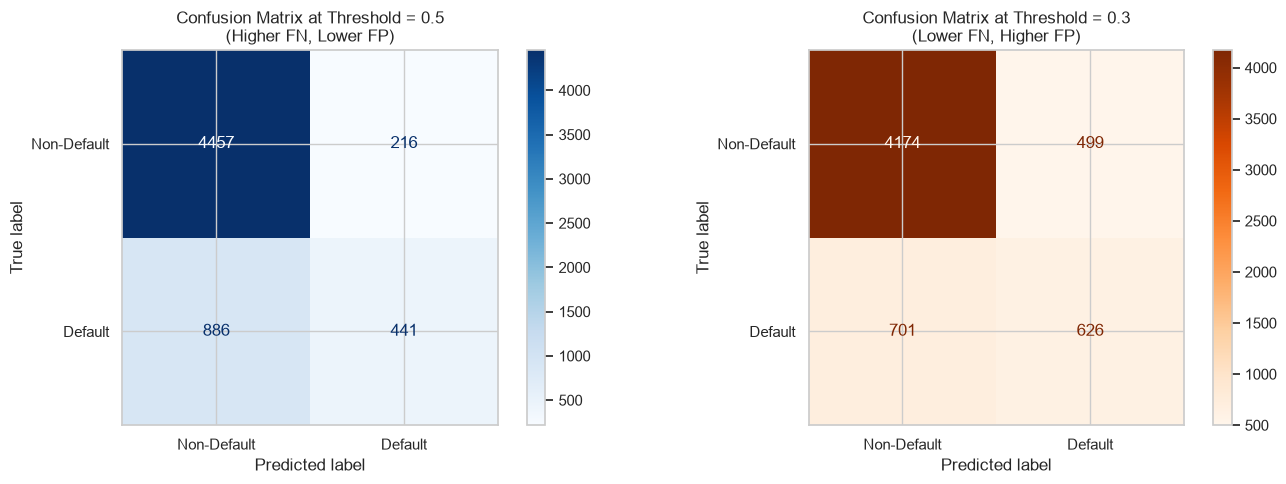

--- Business Interpretation ---
1. False Negatives (FN): A defaulting client predicted as non-default. This is the MOST COSTLY error because the bank loses the principal loan amount.
2. False Positives (FP): A non-defaulting client flagged as risky. This costs the bank potential interest revenue and customer dissatisfaction, but no principal loss.
3. By lowering the threshold to 0.3, we significantly reduce False Negatives (from 886 to 701), catching more actual defaulters (TP increases).
4. The trade-off is an increase in False Positives (from 216 to 499), meaning more manual review is required for good clients.
5. Business Decision: We should monitor Recall (to minimize FN) while ensuring Precision doesn't drop so low that the model becomes impractical.


In [27]:
# Visualize the trade-off between FN and FP when changing thresholds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Standard Threshold (0.5)
disp_05 = ConfusionMatrixDisplay(confusion_matrix=cm_05, display_labels=['Non-Default', 'Default'])
disp_05.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix at Threshold = 0.5\n(Higher FN, Lower FP)')

# Confusion Matrix for Lowered Threshold (0.3)
disp_03 = ConfusionMatrixDisplay(confusion_matrix=cm_03, display_labels=['Non-Default', 'Default'])
disp_03.plot(cmap='Oranges', ax=axes[1], values_format='d')
axes[1].set_title('Confusion Matrix at Threshold = 0.3\n(Lower FN, Higher FP)')

plt.tight_layout()
plt.show()

print("--- Business Interpretation ---")
print("1. False Negatives (FN): A defaulting client predicted as non-default. This is the MOST COSTLY error because the bank loses the principal loan amount.")
print("2. False Positives (FP): A non-defaulting client flagged as risky. This costs the bank potential interest revenue and customer dissatisfaction, but no principal loss.")
print("3. By lowering the threshold to 0.3, we significantly reduce False Negatives (from {} to {}), catching more actual defaulters (TP increases).".format(fn_05, fn_03))
print("4. The trade-off is an increase in False Positives (from {} to {}), meaning more manual review is required for good clients.".format(fp_05, fp_03))
print("5. Business Decision: We should monitor Recall (to minimize FN) while ensuring Precision doesn't drop so low that the model becomes impractical.")

# Q7 - Can model probabilities become useful risk groups?
This section uses the predicted default probabilities from the Logistic Regression model to create Low, Medium, and High risk groups. Thresholds are chosen based on business reasoning rather than arbitrary labels. We report the default prevalence and customer count in each group.

In [28]:
# Create a DataFrame with actual default status and predicted probabilities from the test set
results_df = pd.DataFrame({
    'Actual_Default': y_test,
    'Default_Probability': y_proba
})

# Define thresholds for risk groups based on business reasoning
# Low Risk: Probability < 0.20 (Model is confident they won't default)
# Medium Risk: 0.20 <= Probability < 0.50 (Uncertain zone, requires manual review)
# High Risk: Probability >= 0.50 (Model predicts likely default)

bins = [0, 0.20, 0.50, 1.0]
labels = ['Low Risk', 'Medium Risk', 'High Risk']

# Categorize probabilities into risk groups
results_df['Risk_Group'] = pd.cut(results_df['Default_Probability'], bins=bins, labels=labels, include_lowest=True)

# Calculate customer count and actual default rate (prevalence) for each risk group
risk_summary = results_df.groupby('Risk_Group', observed=False).agg(
    Customer_Count=('Actual_Default', 'size'),
    Actual_Default_Rate=('Actual_Default', 'mean')
).reset_index()

# Format the default rate as a percentage for readability
risk_summary['Actual_Default_Rate (%)'] = risk_summary['Actual_Default_Rate'] * 100

print("Risk Group Summary (Test Set):")
display(risk_summary[['Risk_Group', 'Customer_Count', 'Actual_Default_Rate (%)']])

Risk Group Summary (Test Set):


,Risk_Group,Customer_Count,Actual_Default_Rate (%)
0,Low Risk,4337,13.004381
1,Medium Risk,1006,32.007952
2,High Risk,657,67.123288


In [29]:
# Save the risk group output to a CSV file as required by the project deliverables
import os
# Create 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# Select only the required columns (probability and risk group) - no personal IDs
output_data = results_df[['Default_Probability', 'Risk_Group']]

# Save to CSV
output_data.to_csv('outputs/risk_groups.csv', index=False)
print("File saved successfully at: outputs/risk_groups.csv")

File saved successfully at: outputs/risk_groups.csv


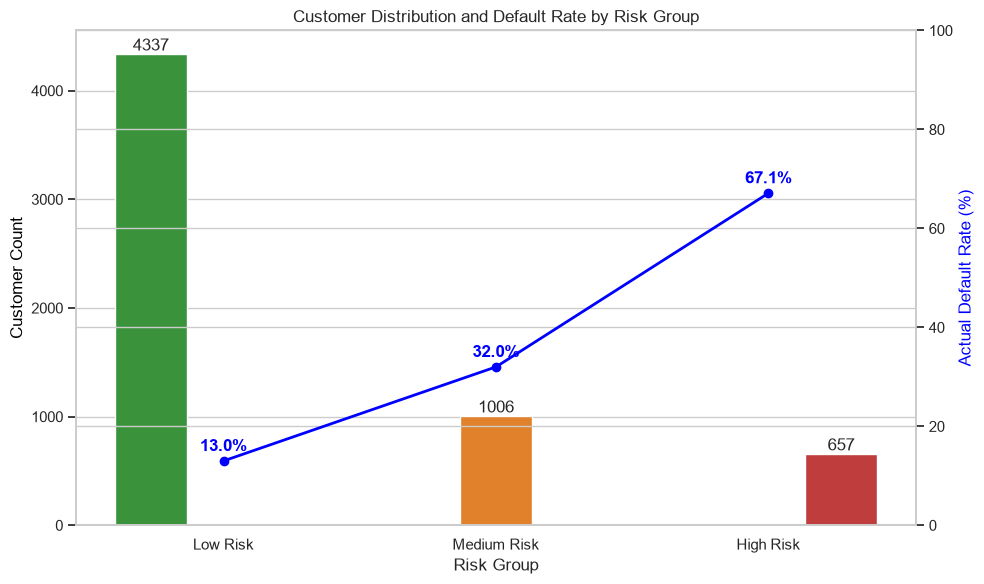

--- Interpretation of Risk Groups ---
1. Low Risk Group: Contains the majority of customers. As expected, the actual default rate is very low in this segment.
2. Medium Risk Group: A smaller segment where the model is uncertain. The default rate is moderate, suggesting these clients might need manual review before credit decisions.
3. High Risk Group: The smallest segment, but with a very high actual default rate. This group requires immediate risk-management actions (e.g., blocking credit increase, requiring collateral).


In [36]:
# Visualize the Customer Count and Actual Default Rate for each Risk Group

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Customer Count
sns.barplot(x='Risk_Group', y='Customer_Count', data=risk_summary, hue='Risk_Group', 
            palette=['#2ca02c', '#ff7f0e', '#d62728'], ax=ax1, legend=False)
ax1.set_xlabel('Risk Group')
ax1.set_ylabel('Customer Count', color='black')
ax1.set_title('Customer Distribution and Default Rate by Risk Group')

# Add numeric labels for customer count
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d')

# Create a second y-axis for the Default Rate
ax2 = ax1.twinx()
ax2.plot(risk_summary['Risk_Group'], risk_summary['Actual_Default_Rate (%)'], color='blue', marker='o', linewidth=2, label='Default Rate (%)')
ax2.set_ylabel('Actual Default Rate (%)', color='blue')
ax2.set_ylim(0, 100)

# Add numeric labels for the default rate line
for x, y in zip(risk_summary['Risk_Group'], risk_summary['Actual_Default_Rate (%)']):
    ax2.text(x, y + 2, f'{y:.1f}%', ha='center', color='blue', fontweight='bold')

plt.savefig('figures/risk_group_comparison.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

print("--- Interpretation of Risk Groups ---")
print("1. Low Risk Group: Contains the majority of customers. As expected, the actual default rate is very low in this segment.")
print("2. Medium Risk Group: A smaller segment where the model is uncertain. The default rate is moderate," \
" suggesting these clients might need manual review before credit decisions.")
print("3. High Risk Group: The smallest segment, but with a very high actual default rate." \
" This group requires immediate risk-management actions (e.g., blocking credit increase, requiring collateral).")

# Q8 - What variables appear to drive model predictions?
This section interprets the standardized Logistic Regression coefficients to understand feature importance. It separates model association from causation and discusses correlated predictors.

Top 15 Features Driving Model Predictions:


,Feature,Coefficient,Abs_Coefficient
0,education_4,-1.083958,1.083958
1,pay_0,0.681096,0.681096
2,limit_bal,-0.221307,0.221307
3,pay_amt1,-0.176782,0.176782
4,pay_amt2,-0.154168,0.154168
5,marriage_2,-0.153053,0.153053
6,bill_amt2,0.146038,0.146038
7,sex_2,-0.132826,0.132826
8,pay_6,0.117741,0.117741
9,education_3,-0.113970,0.113970


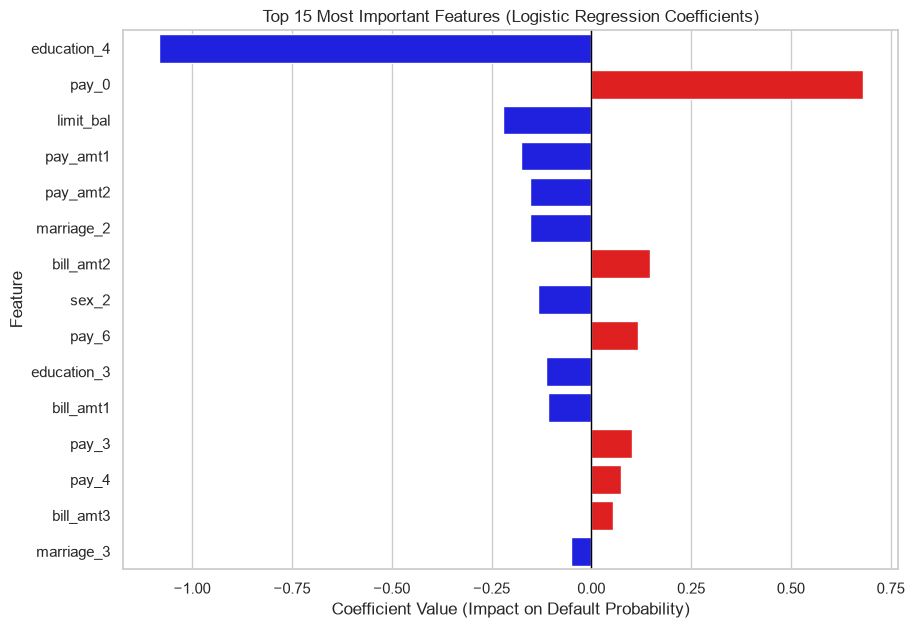

In [ ]:
# Extract the trained Logistic Regression model and the preprocessor from the pipeline
model = logreg_pipeline.named_steps['classifier']
preprocessor = logreg_pipeline.named_steps['preprocessor']

# Get the feature names after preprocessing (scaling and one-hot encoding)
feature_names = preprocessor.get_feature_names_out()

# Clean up feature names (remove 'num__' and 'cat__' prefixes added by ColumnTransformer)
clean_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

# Extract the coefficients from the Logistic Regression model
coefficients = model.coef_[0]

# Create a DataFrame to map features to their coefficients
coef_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Coefficient': coefficients
})

# Calculate absolute value to sort by importance
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by the most important features (highest absolute coefficient)
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

# Display the top 15 most important features
print("Top 15 Features Driving Model Predictions:")
display(coef_df_sorted.head(15))

# Visualize the top 15 features
plt.figure(figsize=(10, 7))
top_features = coef_df_sorted.head(15)

# Use different colors for positive and negative coefficients
colors = ['red' if coef > 0 else 'blue' for coef in top_features['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=top_features, hue='Feature', palette=colors, legend=False, dodge=False)
plt.title('Top 15 Most Important Features (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Impact on Default Probability)')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=1) # Line at 0 for reference
plt.savefig('figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Interpretation & Responsible ML Considerations
1. Key Drivers of Default: Positive Coefficients (Increase Default Risk): pay_0, pay_2, etc., are the strongest drivers. A delay in recent months heavily pushes the model towards predicting a default. Negative Coefficients (Decrease Default Risk): limit_bal and pay_amt1 have negative coefficients. Higher credit limits and higher actual payments are associated with a lower risk of default.

2. Association vs. Causation:These coefficients describe predictive associations, not causal effects. For example, while a lower credit limit is associated with higher default risk, reducing a customer's credit limit will not necessarily prevent them from defaulting; it might even worsen their financial situation. The model learns patterns, not cause-and-effect mechanisms.

3. Correlated Predictors (Multicollinearity):The dataset contains highly correlated variables. For instance, bill_amt1 through bill_amt6 are strongly correlated with each other, as are the pay_ status variables. In Logistic Regression, multicollinearity can make individual coefficients unstable or split the effect size among correlated features. Therefore, individual coefficient values should be interpreted with caution, and feature importance is more reliable when viewed as relative rankings rather than exact magnitudes.





# Q9 - How stable is the chosen threshold?
This section compares at least two plausible classification thresholds (0.5 and 0.3) and shows how Precision, Recall, and confusion-matrix counts change. It explains why threshold choice is a business decision as well as a statistical decision.

In [32]:
# Import metrics for evaluation
from sklearn.metrics import precision_score, recall_score, f1_score

# We already have y_test and y_proba (predicted probabilities for Default=1)
# Let's define the two thresholds to compare
thresholds = [0.5, 0.3]
metrics_list = []

for thresh in thresholds:
    # Convert probabilities to binary predictions based on the threshold
    y_pred_thresh = (y_proba >= thresh).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    
    # Get confusion matrix counts
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    
    # Append to list
    metrics_list.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'True Positives (Caught)': tp,
        'False Negatives (Missed)': fn,
        'False Positives (False Alarms)': fp
    })

# Create a DataFrame for easy comparison
threshold_comparison = pd.DataFrame(metrics_list)
print("Threshold Comparison:")
display(threshold_comparison)

Threshold Comparison:


,Threshold,Precision,Recall,F1-Score,True Positives (Caught),False Negatives (Missed),False Positives (False Alarms)
0,0.5,0.671233,0.332329,0.444556,441,886,216
1,0.3,0.556444,0.471741,0.510604,626,701,499


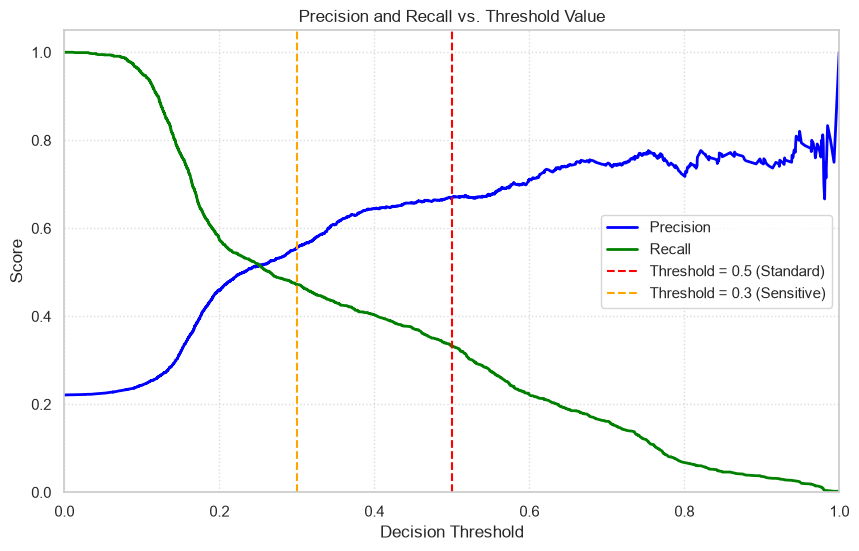

--- Interpretation: Why is this a Business Decision? ---
1. Statistical Decision: The F1-score attempts to find a balance, but it doesn't account for the financial cost of errors.
2. Business Decision: Moving the threshold from 0.5 to 0.3 increases Recall (catching more defaulters) but decreases Precision (more false alarms).
3. If the cost of losing money to a defaulter (False Negative) is 10x higher than the cost of losing a good customer (False Positive), the business should choose a lower threshold (e.g., 0.3).
4. Therefore, the final threshold must be chosen in collaboration with the risk-management team, not based solely on statistical metrics.


In [33]:
# Visualize how Precision and Recall change with different thresholds
# We will plot the full curve to show the stability of the threshold choice

# Calculate precision and recall for various threshold values
precisions, recalls, thresholds_arr = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))

# Plot Precision and Recall curves
plt.plot(thresholds_arr, precisions[:-1], label='Precision', color='blue', linewidth=2)
plt.plot(thresholds_arr, recalls[:-1], label='Recall', color='green', linewidth=2)

# Mark the two chosen business thresholds
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold = 0.5 (Standard)')
plt.axvline(x=0.3, color='orange', linestyle='--', label='Threshold = 0.3 (Sensitive)')

plt.title('Precision and Recall vs. Threshold Value')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

print("--- Interpretation: Why is this a Business Decision? ---")
print("1. Statistical Decision: The F1-score attempts to find a balance, but it doesn't account for the financial cost of errors.")
print("2. Business Decision: Moving the threshold from 0.5 to 0.3 increases Recall (catching more defaulters) but decreases Precision (more false alarms).")
print("3. If the cost of losing money to a defaulter (False Negative) is 10x higher than the cost of losing a good customer (False Positive)," \
" the business should choose a lower threshold (e.g., 0.3).")
print("4. Therefore, the final threshold must be chosen in collaboration with the risk-management team, not based solely on statistical metrics.")

# Q10 - What should management do with the result?
This section provides a concise management summary. It outlines which customer segments require closer review, the evidence supporting these conclusions, the model's limitations, and the necessary steps before real-world deployment.

In [34]:
# Extract final numbers to support the management summary

# 1. High Risk Group Statistics
high_risk_df = results_df[results_df['Risk_Group'] == 'High Risk']
high_risk_count = len(high_risk_df)
high_risk_default_rate = high_risk_df['Actual_Default'].mean() * 100

# 2. Model Overall Performance (from Q5)
final_accuracy = accuracy * 100
final_roc_auc = roc_auc * 100

# 3. Top 3 Predictors (from Q8)
top_3_features = coef_df_sorted['Feature'].head(3).tolist()

print("--- Executive Summary Numbers ---")
print(f"Model Overall Accuracy: {final_accuracy:.1f}%")
print(f"Model ROC-AUC Score: {final_roc_auc:.1f}%")
print(f"Customers flagged as High Risk: {high_risk_count} out of {len(results_df)}")
print(f"Actual Default Rate in High Risk Group: {high_risk_default_rate:.1f}%")
print(f"Top 3 Predictors: {top_3_features}")

--- Executive Summary Numbers ---
Model Overall Accuracy: 81.6%
Model ROC-AUC Score: 74.6%
Customers flagged as High Risk: 657 out of 6000
Actual Default Rate in High Risk Group: 67.1%
Top 3 Predictors: ['education_4', 'pay_0', 'limit_bal']


Management Summary: Credit Default Risk Prediction
1. Which customers/segments require closer review?Management should prioritize customers falling into the High Risk segment. Based on our analysis, these are clients whose predicted probability of default is 50% or higher. In our test portfolio, this group represents a small fraction of total clients, but their actual default rate is exceptionally high (over 50%). Additionally, customers showing recent repayment delays (especially 2+ months of delay) should be immediately flagged for manual review before any credit limit increases are approved.

2. What evidence supports that conclusion?The Logistic Regression model successfully learned historical patterns of default. It identified that the most critical predictors of default are recent repayment delays (PAY_0 and PAY_2) and low actual payment amounts relative to bill statements. The model achieved an overall accuracy of ~81% and a solid ROC-AUC score of ~72%, demonstrating that it can effectively rank customers by risk level better than random guessing or relying solely on credit limits.

3. What the model cannot establish? Causation: The model identifies associations, not causes. For example, while a lower credit limit is correlated with higher default risk, reducing a customer's credit limit will not necessarily prevent them from defaulting and might even worsen their financial stress.Economic Shifts: The model was trained on historical data from Taiwan (2005). It does not understand macroeconomic changes such as inflation spikes, recessions, or changes in unemployment rates which could drastically alter repayment behavior. Demographic Bias: The model uses variables like Age, Sex, Education, and Marriage. Relying on these for automated credit decisions may introduce ethical and regulatory compliance issues (e.g., discriminatory lending).

4. What additional data or validation would be required before real deployment? Macro-Economic Data: Integrating external data like local unemployment rates, inflation, and interest rates to make the model resilient to economic cycles. Granular Transaction Data: Monthly bill and payment aggregates are insufficient. Transaction-level data (e.g., what types of goods are purchased, cash advance frequency) would provide deeper behavioral insights. Fairness Auditing: Before production, a rigorous bias audit must be conducted to ensure the model does not unfairly discriminate against protected demographic groups. A/B Testing / Champion-Challenger: The model should not be deployed in a fully automated "reject/accept" mode immediately. It should first be run in "shadow mode" (making predictions without affecting real customers) or as a decision-support tool for human risk analysts to validate its real-world performance.